In [126]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')


In [127]:
df=pd.read_csv("amazon_review-selected-columns.csv")

In [128]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513


In [129]:
df.shape

(4915, 10)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      4915 non-null   object 
 1   asin            4915 non-null   object 
 2   reviewerName    4914 non-null   object 
 3   helpful         4915 non-null   object 
 4   reviewText      4914 non-null   object 
 5   overall         4915 non-null   float64
 6   summary         4915 non-null   object 
 7   unixReviewTime  4915 non-null   int64  
 8   reviewTime      4915 non-null   object 
 9   day_diff        4915 non-null   int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 384.1+ KB


In [131]:
df.describe()

,overall,unixReviewTime,day_diff
count,4915.000000,4.915000e+03,4915.000000
mean,4.587589,1.379465e+09,437.367040
std,0.996845,1.581857e+07,209.439871
min,1.000000,1.339200e+09,1.000000
25%,5.000000,1.365898e+09,281.000000
50%,5.000000,1.381277e+09,431.000000
75%,5.000000,1.392163e+09,601.000000
max,5.000000,1.406074e+09,1064.000000


In [132]:
df.duplicated().sum()

np.int64(0)

In [133]:
df.isnull().sum()

reviewerID        0
asin              0
reviewerName      1
helpful           0
reviewText        1
overall           0
summary           0
unixReviewTime    0
reviewTime        0
day_diff          0
dtype: int64

In [134]:
df.dropna(inplace=True)

In [135]:
df.isnull().sum()

reviewerID        0
asin              0
reviewerName      0
helpful           0
reviewText        0
overall           0
summary           0
unixReviewTime    0
reviewTime        0
day_diff          0
dtype: int64

In [136]:
df['overall'].value_counts()

overall
5.0    3921
4.0     526
1.0     244
3.0     142
2.0      80
Name: count, dtype: int64

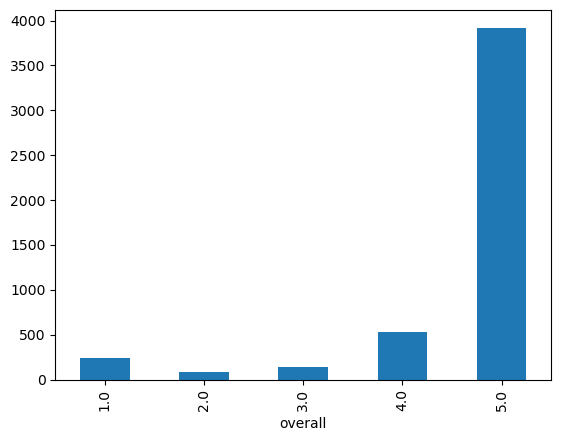

In [137]:
df['overall'].value_counts().sort_index().plot(kind='bar')
plt.show()

In [138]:
df['review_length'] = df['reviewText'].str.len()

In [139]:
df['review_length'].describe()

count    4913.000000
mean      267.799919
std       328.877502
min         3.000000
25%       123.000000
50%       172.000000
75%       289.000000
max      8638.000000
Name: review_length, dtype: float64

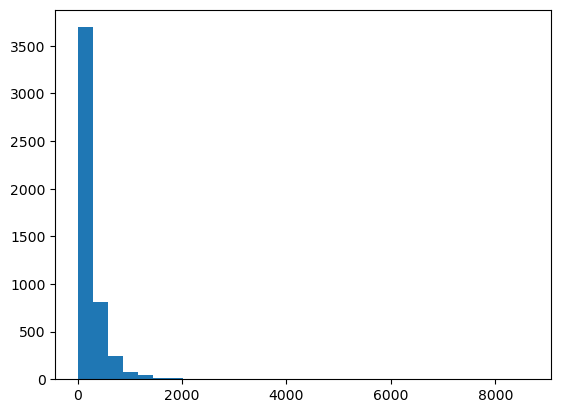

In [140]:
plt.hist(df['review_length'], bins=30)
plt.show()

In [141]:
def sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["overall"].apply(sentiment)

In [142]:
df["Sentiment"].value_counts()

Sentiment
Positive    4447
Negative     324
Neutral      142
Name: count, dtype: int64

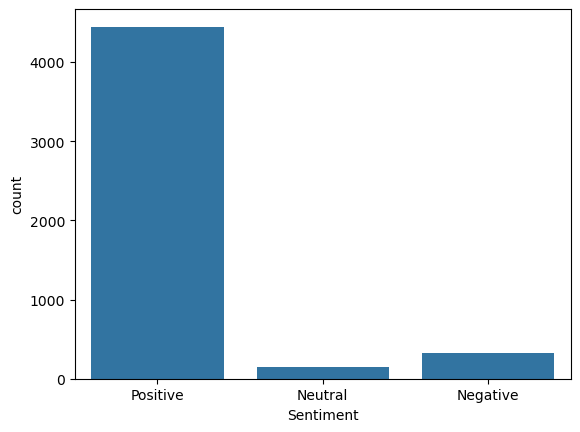

In [143]:
sns.countplot(x="Sentiment", data=df)
plt.show()

In [144]:
import re
import string
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rishitabagri/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rishitabagri/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rishitabagri/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rishitabagri/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/rishitabagri/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [145]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [146]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenize
    words = word_tokenize(text)

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    # lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [147]:
df["clean_review"] = df["reviewText"].apply(clean_text)

In [148]:
df[['reviewText','clean_review']].head(10)

,reviewText,clean_review
1,"Purchased this for my device, it worked as adv...",purchased device worked advertised never much ...
2,it works as expected. I should have sprung for...,work expected sprung higher capacity think mad...
3,This think has worked out great.Had a diff. br...,think worked greathad diff bran gb card went s...
4,"Bought it with Retail Packaging, arrived legit...",bought retail packaging arrived legit orange e...
5,It's mini storage. It doesn't do anything els...,mini storage doesnt anything else supposed pur...
6,I have it in my phone and it never skips a bea...,phone never skip beat file transfer speedy cor...
7,It's hard to believe how affordable digital ha...,hard believe affordable digital become gb devi...
8,Works in a HTC Rezound. Was running short of ...,work htc rezound running short space gb sandis...
9,"in my galaxy s4, super fast card, and am total...",galaxy super fast card totally happy happy sti...
10,I like this SD Card because it can take music ...,like sd card take music video downloads person...


In [149]:
X = df["clean_review"]
y = df["Sentiment"]

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [151]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3930,)
(983,)
(3930,)
(983,)


In [152]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

In [153]:
print(X_train_cv.shape)
print(X_test_cv.shape)

(3930, 7937)
(983, 7937)


In [154]:
print(len(cv.vocabulary_))

7937


In [155]:
print(list(cv.vocabulary_.keys())[:20])

['go', 'pro', 'hero', 'black', 'work', 'good', 'hold', 'ton', 'video', 'pic', 'fair', 'price', 'shopping', 'around', 'thanks', 'prime', 'maximum', 'take', 'wanted', 'many']


In [156]:
print(cv.get_feature_names_out()[:20])

['aa' 'aac' 'aba' 'abdroid' 'ability' 'able' 'aboutgood' 'abouti'
 'abouttherehere' 'aboutto' 'abovei' 'abroad' 'abruptly' 'absolute'
 'absolutely' 'abuse' 'abused' 'abysmal' 'accept' 'acceptable']


In [157]:
bow = pd.DataFrame(
    X_train_cv.toarray(),
    columns=cv.get_feature_names_out()
)

bow.head()

,aa,aac,aba,abdroid,ability,able,aboutgood,abouti,abouttherehere,aboutto,...,zerogb,zip,zl,zone,zoning,zoom,zte,ztpad,zumo,zune
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [158]:
from sklearn.naive_bayes import MultinomialNB

In [159]:
nb = MultinomialNB()

In [160]:
nb.fit(X_train_cv, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [161]:
y_pred = nb.predict(X_test_cv)

In [162]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9175991861648016


In [163]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.60      0.40      0.48        65
     Neutral       0.00      0.00      0.00        28
    Positive       0.93      0.98      0.96       890

    accuracy                           0.92       983
   macro avg       0.51      0.46      0.48       983
weighted avg       0.88      0.92      0.90       983



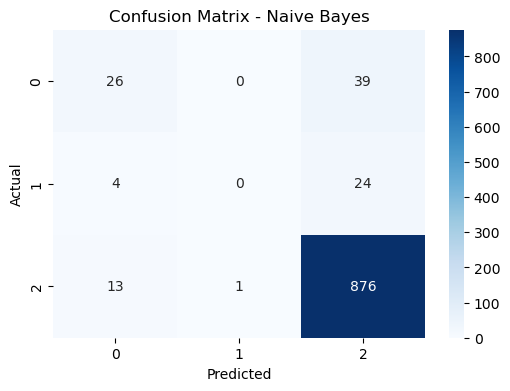

In [164]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [165]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [166]:
tfidf = TfidfVectorizer()

In [167]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [168]:
from sklearn.linear_model import LogisticRegression

In [169]:
lr = LogisticRegression(max_iter=1000)

In [170]:
lr.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [171]:
y_pred_lr = lr.predict(X_test_tfidf)

In [172]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.9247202441505595


In [173]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    Negative       0.87      0.31      0.45        65
     Neutral       0.00      0.00      0.00        28
    Positive       0.93      1.00      0.96       890

    accuracy                           0.92       983
   macro avg       0.60      0.44      0.47       983
weighted avg       0.90      0.92      0.90       983



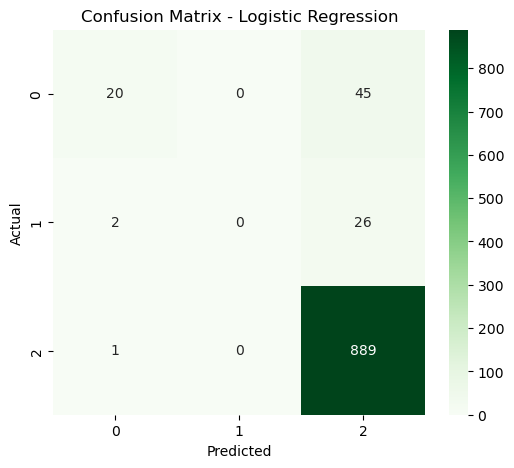

In [174]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [175]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

In [176]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9277721261444557
              precision    recall  f1-score   support

    Negative       0.75      0.42      0.53        65
     Neutral       0.00      0.00      0.00        28
    Positive       0.94      0.99      0.96       890

    accuracy                           0.93       983
   macro avg       0.56      0.47      0.50       983
weighted avg       0.90      0.93      0.91       983



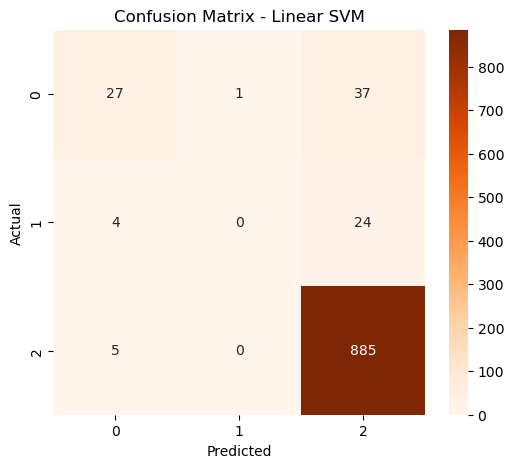

In [177]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [178]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Vectorizer": [
        "CountVectorizer",
        "TF-IDF",
        "TF-IDF"
    ],
    "Accuracy": [
        91.75,
        92.47,
        92.78
    ]
})

comparison

,Model,Vectorizer,Accuracy
0,Naive Bayes,CountVectorizer,91.75
1,Logistic Regression,TF-IDF,92.47
2,Linear SVM,TF-IDF,92.78
